In [1]:
# ===================================
# 1. Import Libraries
# ===================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option(
    'display.max_columns',
    None
)

In [2]:
# ===================================
# 2. Load Data
# ===================================


df = pd.read_csv(
    "/Users/wuchaoqun/Desktop/Project1/raw data/customer_order_analysis.csv"
)


df.head()

,order_id,customer_unique_id,order_purchase_timestamp,product_id,price,freight_value,order_amount,payment_value,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,18.12,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,2.00,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,18.59,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,141.46,141.46,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,179.12,179.12,vianopolis,GO


In [3]:
df.shape

(115038, 10)

In [4]:
df.columns

Index(['order_id', 'customer_unique_id', 'order_purchase_timestamp',
       'product_id', 'price', 'freight_value', 'order_amount', 'payment_value',
       'customer_city', 'customer_state'],
      dtype='object')

In [5]:
# ===================================
# 3. Data Cleaning
# ===================================


df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

In [6]:
df = df.dropna(
    subset=[
        'customer_unique_id'
    ]
)

In [7]:
# ===================================
# 4. Customer Order Level Data
# ===================================


customer_orders = (

    df[
        [
            'order_id',
            'customer_unique_id',
            'order_purchase_timestamp'
        ]
    ]

    .drop_duplicates()

)

In [8]:
customer_orders.shape

(96478, 3)

In [9]:
customer_orders.head()

,order_id,customer_unique_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
5,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
6,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


In [10]:
# ===================================
# 5. Create Order Month
# ===================================


customer_orders['order_month'] = (

    customer_orders['order_purchase_timestamp']

    .dt

    .to_period('M')

)

In [11]:
customer_orders.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08
5,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11
6,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02


In [12]:
# ===================================
# 6. Cohort Month
# ===================================


customer_orders['cohort_month'] = (

    customer_orders

    .groupby(
        'customer_unique_id'
    )

    ['order_month']

    .transform(
        'min'
    )

)

In [13]:
customer_orders.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_month,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10,2017-09
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08
5,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11
6,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02


In [14]:
# ===================================
# 7. Cohort Index
# ===================================


customer_orders['cohort_index'] = (

    (
        customer_orders['order_month'].dt.year
        -
        customer_orders['cohort_month'].dt.year
    )

    *12

    +

    (
        customer_orders['order_month'].dt.month
        -
        customer_orders['cohort_month'].dt.month
    )

)

In [15]:
customer_orders.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_month,cohort_month,cohort_index
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10,2017-09,1
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07,0
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08,0
5,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11,0
6,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02,0


In [16]:
# ===================================
# 8. Cohort User Count
# ===================================


cohort_data = (

    customer_orders

    .groupby(
        [
            'cohort_month',
            'cohort_index'
        ]
    )

    [
        'customer_unique_id'
    ]

    .nunique()

    .reset_index()

)


cohort_data.head()

,cohort_month,cohort_index,customer_unique_id
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1


In [17]:
# ===================================
# 9. Cohort Matrix
# ===================================


cohort_table = (

    cohort_data

    .pivot_table(

        index='cohort_month',

        columns='cohort_index',

        values='customer_unique_id'

    )

)


cohort_table.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN


In [18]:
# ===================================
# 10. Retention Rate
# ===================================


retention_table = (

    cohort_table

    .divide(

        cohort_table.iloc[:,0],

        axis=0

    )

)

In [19]:
retention_percentage = (

    retention_table

    *100

)


retention_percentage.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.381679,NaN,NaN,0.381679,NaN,0.381679,NaN,0.381679,NaN,0.381679,NaN,0.381679,0.763359,0.763359
2016-12,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.278940,0.278940,0.13947,0.418410,0.13947,0.418410,0.139470,0.13947,NaN,0.41841,0.139470,0.69735,0.418410,0.13947,0.139470,0.278940,0.418410,0.139470,NaN
2017-02,100.0,0.184275,0.307125,0.12285,0.429975,0.12285,0.245700,0.184275,0.12285,0.184275,0.12285,0.307125,0.12285,0.184275,0.12285,0.061425,0.061425,0.184275,NaN,NaN


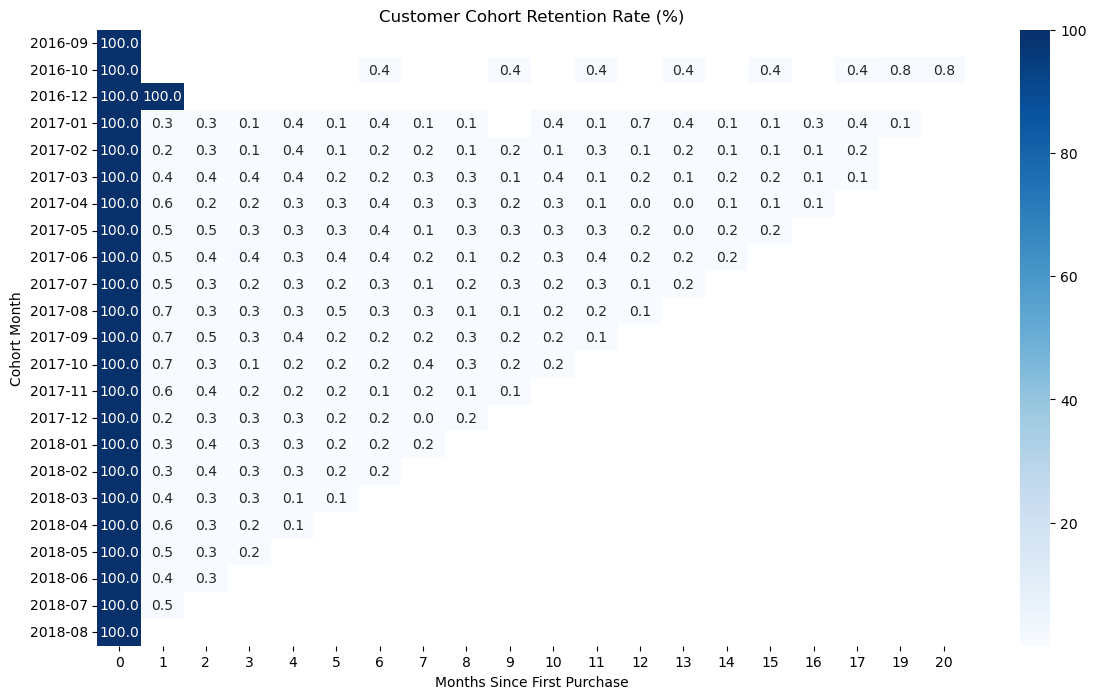

In [20]:
# ===================================
# 11. Visualization
# ===================================


plt.figure(
    figsize=(14,8)
)


sns.heatmap(

    retention_percentage,

    annot=True,

    fmt=".1f",

    cmap="Blues"

)


plt.title(
    "Customer Cohort Retention Rate (%)"
)


plt.xlabel(
    "Months Since First Purchase"
)


plt.ylabel(
    "Cohort Month"
)


plt.show()

In [21]:
# ===================================
# 12. Tableau Format
# ===================================


tableau_retention = (

    retention_percentage

    .reset_index()

    .melt(

        id_vars=[
            'cohort_month'
        ],

        var_name=
        'month_number',

        value_name=
        'retention_rate'

    )

)

In [22]:
tableau_retention.head(10)

,cohort_month,month_number,retention_rate
0,2016-09,0,100.0
1,2016-10,0,100.0
2,2016-12,0,100.0
3,2017-01,0,100.0
4,2017-02,0,100.0
5,2017-03,0,100.0
6,2017-04,0,100.0
7,2017-05,0,100.0
8,2017-06,0,100.0
9,2017-07,0,100.0


In [24]:
# ===================================
# 13. Export
# ===================================


tableau_retention.to_csv(

    "/Users/wuchaoqun/Desktop/Project1/raw data/cohort_retention_tableau.csv",

    index=False

)